### W02C --- Discretized harmonic oscillator

In [23]:
import numpy as np
import matplotlib.pyplot as plt

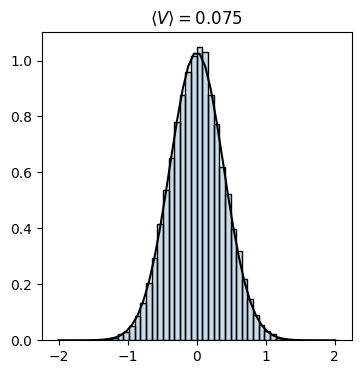

In [ ]:
class Node:
    def __init__(self , index , energy):
        self.index = index
        self.energy = energy

class System():
    def __init__(self, Tij, k=1, kT=0.15, xmin=-1, xmax=1, N_sites=100):
        self.k = k
        self.kT = kT
        self.N_sites = N_sites
        self.Tij = Tij
        self.x = np.linspace(xmin,xmax,N_sites)
        self.energies = 1/2 * self.k * self.x**2
        self.nodes = [Node(i,e) for i,e in enumerate(self.energies)]
        self.state = self.nodes[0]
        self.counts = self.run_Metropolis_Monte_Carlo()
        self.p_exact = np.sqrt(self.k/(2* np.pi*self.kT))*np.exp(-self.energies/kT)

    def plot(self, ax):
        xwidth = self.x[1]-self.x[0]
        P = self.counts/xwidth
        ax.bar(self.x, P, width=xwidth, facecolor ='C0', alpha =0.25)
        ax.bar(self.x, P, width=xwidth, facecolor ='None', edgecolor ='k')
        ax.set_title(r'$\langle V\rangle=$'+f'{self.thermal_avg():.3f}')
        ax.plot(self.x, self.p_exact, 'k')
    
    def proposed_state(self):
        p_states = self.Tij[self.state.index]
        j = np.random.choice(np.arange(self.N_sites), p=p_states)
        return self.nodes[j]
    
    def step(self):
        proposed_state = self.proposed_state()
        delta_V = proposed_state.energy - self.state.energy
        acceptance_probability = min(1, np.exp(-delta_V / self.kT))  # using P(x')/P(x) = exp(-E'/kT)/exp(E/kT) = exp(-delta_E/kT)
        if np.random.rand() < acceptance_probability:
            self.state = proposed_state

    def run_Metropolis_Monte_Carlo(self, n_steps=100000):
        self.visited_states = []
        for _ in range(n_steps):
            self.step()
            self.visited_states.append(self.state.index)
        counts = np.bincount(self.visited_states, minlength=self.N_sites)  # count the states
        return counts/np.sum(counts)  # get mmc probabilites

    def thermal_avg(self):
        return np.mean(self.energies[self.visited_states])
    

N_sites = 50
Tij = np.array([[1/N_sites]*N_sites]*N_sites)
s = System(Tij=Tij, xmin=-2, xmax=2, N_sites=N_sites)
fig, axes = plt.subplots(1,1,figsize=(4,4))
s.plot(axes)


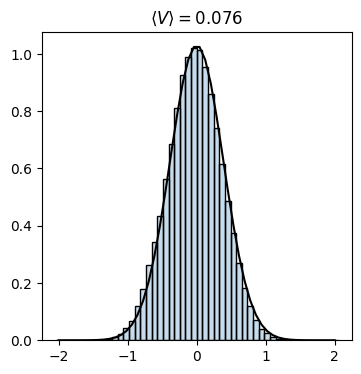

In [77]:
N_sites = 50
varied_Tij = np.array([np.zeros(N_sites)]*N_sites)
varied_Tij[0,0]=1/2
varied_Tij[N_sites-1,N_sites-1] = 1/2
for i in range(N_sites - 1):
    varied_Tij[i, i+1] = 1/2
    varied_Tij[i+1, i] = 1/2

s = System(Tij=varied_Tij, xmin=-2, xmax=2, N_sites=N_sites)
fig, axes = plt.subplots(1,1,figsize=(4,4))
s.plot(axes)